# Consistency benchmarks

Quantifying consistency of implemented protocols in terms of dirty reads, synchrony violations, latency and throughput.

Benchmark used: YCSB A, B, high_contention

MONSTER protocol params:

- round_time
- read_retries
- read_offset

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## YCSB A - 9nodes

In [2]:
async_best_effort = [
    {
        "read_retries": 0,
        "dr_percent": 5580 / 1005193,
        "read_avg": 3860, "read_p99": 2060, "read_p9999": 10330000, "read_p100": 19660000,
        "write_avg": 1300, "write_p99": 1830, "write_p999": 5100, "write_p100": 2560000,
        "tput": 374392,
    },
    {
        "read_retries": 1,
        "dr_percent": 639 / 1005007,
        "read_avg": 2070, "read_p99": 2040, "read_p9999": 4480000, "read_p100": 16000000,
        "write_avg": 1300, "write_p99": 1830, "write_p999": 5410, "write_p100": 2820000,
        "tput": 480625,
    },
    {
        "read_retries": 10,
        "dr_percent": 291 / 1004897,
        "read_avg": 2250, "read_p99": 2070, "read_p9999": 1810000, "read_p100": 16470000,
        "write_avg": 1300, "write_p99": 1840, "write_p999": 5160, "write_p100": 2660000,
        "tput": 533659,
    },
    {
        "read_retries": 100,
        "dr_percent": 112 / 10010651,
        "read_avg": 1910, "read_p99": 2100, "read_p9999": 160000, "read_p100": 19150000,
        "write_avg": 1300, "write_p99": 1870, "write_p999": 5250, "write_p100": 3950000,
        "tput": 588725,
    },
    {
        "read_retries": 1000,
        "dr_percent": 20 / 1004104,
        "read_avg": 1750, "read_p99": 2100, "read_p9999": 180000, "read_p100": 17150000,
        "write_avg": 1300, "write_p99": 1870, "write_p999": 5250, "write_p100": 4550000,
        "tput": 620122,
    },
]


######################## monster
monster1us = [
    {
        "read_retries": 0,
        "dr_percent": 4889 / 10003905,
        "read_avg": 1060, "read_p99": 1570, "read_p9999": 6080, "read_p100": 10994166,
        "write_avg": 4030, "write_p99": 5100, "write_p999": 8590, "write_p100": 11334906,
        "tput": 378281,
    },
    {
        "read_retries": 1,
        "dr_percent": 1 / 10010651,
        "read_avg": 1060, "read_p99": 1590, "read_p9999": 5390, "read_p100": 12410000,
        "write_avg": 1010, "write_p99": 1340, "write_p999": 4520, "write_p100": 11910000,
        "tput": 378325,
    },
    {
        "read_retries": 10,
        "dr_percent": 1 / 10010651,
        "read_avg": 1050, "read_p99": 1570, "read_p9999": 4420, "read_p100": 11590000,
        "write_avg": 4040, "write_p99": 5040, "write_p999": 10400, "write_p100": 11760000,
        "tput": 376637,
    },
    {
        "read_retries": 100,
        "dr_percent": 0 / 10010651,
        "read_avg": 1070, "read_p99": 1590, "read_p9999": 4340, "read_p100": 11400000,
        "write_avg": 4040, "write_p99": 5015, "write_p999": 11400, "write_p100": 11660000,
        "tput": 376732,
    },
]

monster50ns = [
    {
        "read_retries": 10,
        "dr_percent": 2 / 10010651,
        "read_avg": 1060, "read_p99": 1570, "read_p9999": 4450, "read_p100": 11410000,
        "write_avg": 2970, "write_p99": 3440, "write_p999": 7030, "write_p100": 11260000,
        "tput": 472898,
    },
    {
        "read_retries": 100,
        "dr_percent": 3 / 10010651,
        "read_avg": 1060, "read_p99": 1580, "read_p9999": 5550, "read_p100": 11520000,
        "write_avg": 2980, "write_p99": 3460, "write_p999": 8290, "write_p100": 11860000,
        "tput": 471805,
    },
]

In [17]:
df = pd.DataFrame(async_best_effort)
df["label"] = "abe"

dfm = pd.DataFrame(monster1us)
dfm["label"] = "monster"
df = pd.concat([df, dfm])

dfm = pd.DataFrame(monster50ns)
dfm["label"] = "monster_async"
df = pd.concat([df, dfm])

In [18]:
df

,read_retries,dr_percent,read_avg,read_p99,read_p9999,read_p100,write_avg,write_p99,write_p999,write_p100,tput,label
0,0,1.217924e-03,1070,1620,5100,12074166,1010,1370,4900,12434906,881246,abe
1,1,7.951531e-05,1070,1640,4700,12410000,1010,1340,4520,11910000,881191,abe
2,10,3.406372e-05,1080,1640,5350,11950000,1010,1330,4650,11910000,878767,abe
3,100,2.117744e-05,1080,1640,8060,11840000,1010,1330,4650,11970000,876984,abe
4,1000,1.648244e-05,1140,1640,8820,12000000,1010,1330,4650,11970000,852616,abe
5,10000,1.309489e-05,1660,1630,7350,23000000,1010,1330,4650,11970000,852616,abe
0,0,4.887092e-04,1060,1570,6080,10994166,4030,5100,8590,11334906,378281,monster
1,1,9.989360e-08,1060,1590,5390,12410000,1010,1340,4520,11910000,378325,monster
2,10,9.989360e-08,1050,1570,4420,11590000,4040,5040,10400,11760000,376637,monster
3,100,0.000000e+00,1070,1590,4340,11400000,4040,5015,11400,11660000,376732,monster


<Axes: xlabel='read_retries'>

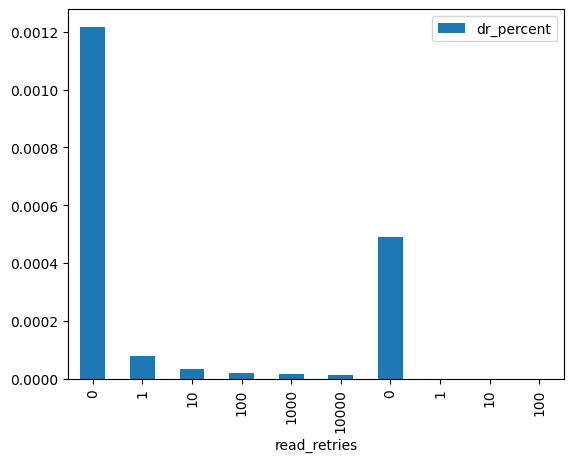

In [13]:
# fig, ax = plt.subplots()
df.plot(x="read_retries", y=["dr_percent"], kind="bar")

## Synchrony tests & read retries

Test the effect of read retries and synchrony in MONSTER and ABE.


In [130]:
read_retries = [0, 1, 10, 100, 1000]

# 9 processes (low contention)
print("9 processes, ycab a low contention")

p9_abe_tput = [ 374001.05, 480625, 517672, 587166, 620122]
p9_abe_dr = [ 0.567, 0.061, 0.032, 0.010, 9 / 1005241]
# 0% sync
p9_monster10r_tput = [ 231000, 323000, 325026, 325705, 325705] 
p9_monster10r_dr = [ 0.148, 11 / 1005092, 2 / 1005678,  3 / 1005678, 3 / 1005678]
# 
print(f'1200r sync rate: {1 - 791328/1005007} ')
p9_monster1200r_tput = [215009, 272127, 272980, 272669, 272669]
p9_monster1200r_dr = [885 / 1005678, 6 / 1003285, 1 / 1004897, 1 / 1003285, 1 / 1003285]
#
print(f'1300r sync rate: {1 - 249138 / 1005193} ')
p9_monster1300r_tput = [197428, 273964, 273754, 273752, 273752 ]
p9_monster1300r_dr = [0.162, 5 / 1005092, 1 / 1005007, 1 / 1005193, 1 / 1005193 ]
#
print(f'1400r sync rate: {1 - 211598 / 1005193} ')
p9_monster1400r_tput = [184278, 267237, 269381, 269792, 269792 ]
p9_monster1400r_dr = [ 2178 / 1005193, 7 / 1005193, 1 / 1003285, 1 / 1003285 ]
#
print(f'1500r sync rate: {1 - 119602 / 1005193} ')
p9_monster1500r_tput = [182000, 259687, 259554, 259910, 259910 ]
p9_monster1500r_dr = [ 2353 / 1004897, 3 / 1003285, 2 / 1005678, 1 / 1005678, 1 / 1005678 ]
#
print(f'1700r sync rate: {1 - 10325 / 1005193} ')
p9_monster1700r_tput = [ 197909, 233959, 233451, 233743, 233743 ]
p9_monster1700r_dr = [ 536 / 1005193, 4 / 1005193,  1 / 1005193, 1 / 1005193, 1 / 1005193 ]

# 64 processes (medium contention)
print("64 processes  ycsb a (medium contention)")

p64_abe_tput = [ 176353, 196211, 200966, 239067, 232605]
p64_abe_dr = [ 35973 / 1004710, 19278 / 1004710, 5068 / 1005399, 152 / 1004813, 1 / 1004813] 
# 0% sync
p64_monster10r_tput = [79290, 103688, 104174, 104422, 104422] 
p64_monster10r_dr = [ 5241 / 1004813, 120 / 1004506, 4 / 1005511, 4 / 1005511]
# 
print(f'1300r sync rate: {1 - 898928 / 1005193} ')
p64_monster1300r_tput = [ 115000, 18200, 18600, 189000, 189000 ]
p64_monster1300r_dr = [8481 / 1004710, 129 / 1004637, 1 / 1004967, 1 / 1004967, 1 / 1004967, 1 / 1004967 ]
# 
print(f'1500r sync rate: {1 - 642958 / 1005193} ')
p64_monster1500r_tput = [ 111000, 180000, 185000, 185000, 185000 ]
p64_monster1500r_dr = [8705 / 1006615, 104 / 1004710, 1 / 1005283, 1 / 1005283, 1 / 1005283 ]
# 
print(f'1700r sync rate: {1 - 392891 / 1005193} ')
p64_monster1700r_tput = [118000, 175000, 181000, 181000, 181000 ]
p64_monster1700r_dr = [ 9625 / 1004967, 91 / 1004813, 1 / 1004813, 1 / 1004813, 1 / 1004813 ]
# 
print(f'2000r sync rate: {1 - 205225 / 1005193} ')
p64_monster2000r_tput = [118000, 173000, 174000, 174000, 174000 ]
p64_monster2000r_dr = [ 5769 / 1004710, 2 / 1004637, 1 / 1004967, 1 / 1004967, 1 / 1004967 ]
# 
print(f'3100r sync rate: {1 - 9183 / 1005193} ')
p64_monster3100r_tput = [88000, 145000, 145000, 145000, 145000 ]
p64_monster3100r_dr = [ 7648 / 1005551, 6 / 1004967, 1 / 1004967, 1 / 1004967, 1 / 1004967 ]


# 9 processes, ycsb a single key (extreme contention)
print("9 processes, ycsb a single key (medium contention)")

p9sk_abe_tput = [ 126506, 117395, 82000, 44120, 7718 ]
p9sk_abe_dr = [ 417142 / 1005610, 316983 / 1005627, 59332 / 1005520, 24381 / 1006520, 25564 / 1005520 ] 
# 0% sync
p9sk_monster10r_tput = [85000, 94500, 112000, 111000, 111000  ] 
p9sk_monster10r_dr = [ 106407 / 1005670, 7182 / 1005244, 1 / 1005627, 1 / 1005627, 1 / 1005627 ]
# 
print(f'1200r sync rate: {1 - 755871 / 1005193} ')
p9sk_monster1200r_tput = [ 80000, 101000, 122750, 121625, 120625  ]
p9sk_monster1200r_dr = [66927 / 1004063, 2180 / 1005610, 1 / 1006520, 1 / 1006520, 1 / 1006520 ]
# 
print(f'1500r sync rate: {1 - 252401 / 1005193} ')
p9sk_monster1500r_tput = [ 80375, 108740, 127375,  127000, 127000  ]
p9sk_monster1500r_dr = [ 88696 / 1004063, 2019 / 1004063, 2 / 1004063, 1 / 1004063, 1 / 1004063]
# 
print(f'2500r sync rate: {1 - 6951 / 1005193} ')
p9sk_monster2500r_tput = [ 71250, 110875, 113875, 113875, 113875 ]
p9sk_monster2500r_dr = [ 49424 / 1005610, 74 / 1005610, 2 / 1005670, 2 / 1005670, 2 / 1005670]

9 processes, ycab a low contention
1200r sync rate: 0.21261443950141645 
1300r sync rate: 0.7521490897767891 
1400r sync rate: 0.7894951516773396 
1500r sync rate: 0.8810158845117306 
1700r sync rate: 0.9897283407266068 
64 processes  ycsb a (medium contention)
1300r sync rate: 0.1057160167251463 
1500r sync rate: 0.36036363166078555 
1700r sync rate: 0.6091387425101449 
2000r sync rate: 0.7958352276627474 
3100r sync rate: 0.9908644409581046 
9 processes, ycsb a single key (medium contention)
1200r sync rate: 0.24803395964755026 
1500r sync rate: 0.7489029469962485 
2500r sync rate: 0.9930849100620478 


In [131]:
(146+130+116+110+105+103+101+100) /8

113.875

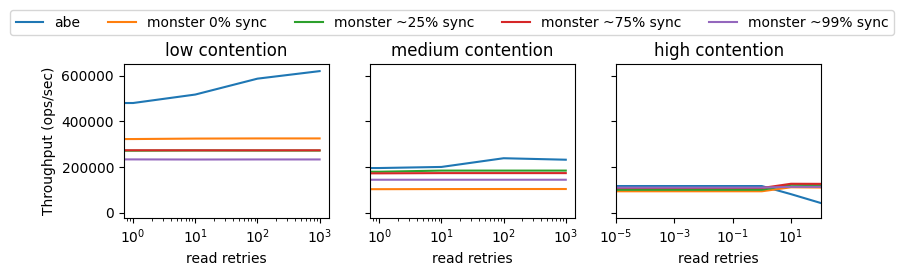

In [147]:
fig, axs = plt.subplots(1,3, sharey="all", figsize=(9, 2))

ax = axs[0]
ax.set_title("low contention")
ax.plot(read_retries, p9_abe_tput, label="abe")
ax.plot(read_retries, p9_monster10r_tput, label="monster 0% sync")
ax.plot(read_retries, p9_monster1200r_tput, label="monster 21% sync")
ax.plot(read_retries, p9_monster1300r_tput, label="monster 75% sync")
ax.plot(read_retries, p9_monster1700r_tput, label="monster 98% sync")

ax.set_ylabel("Throughput (ops/sec)")
ax.set_xlabel("read retries")

# ax.legend(loc="center", bbox_to_anchor=(2,1.6), ncols=5)
ax.set_xscale("log")
# ax.set_yscale("log")

ax = axs[1]
ax.set_title("medium contention")
ax.plot(read_retries, p64_abe_tput, label="abe")
ax.plot(read_retries, p64_monster10r_tput, label="monster 0% sync")
ax.plot(read_retries, p64_monster1500r_tput, label="monster 31% sync")
ax.plot(read_retries, p64_monster2000r_tput, label="monster 79% sync")
ax.plot(read_retries, p64_monster3100r_tput, label="monster 99% sync")
# ax.plot(read_retries, p64_monster1700r_tput, label="monster 98% sync")
# ax.legend(loc="center", bbox_to_anchor=(0.6,1.4), ncols=5)
ax.set_xscale("log")
ax.set_xlabel("read retries")


ax = axs[2]
ax.set_title("high contention")
ax.plot(read_retries, p9sk_abe_tput, label="abe")
ax.plot(read_retries, p9sk_monster10r_tput, label="monster 0% sync")
ax.plot(read_retries, p9sk_monster1200r_tput, label="monster ~25% sync")
ax.plot(read_retries, p9sk_monster1500r_tput, label="monster ~75% sync")
ax.plot(read_retries, p9sk_monster2500r_tput, label="monster ~99% sync")

ax.set_xlabel("read retries")
ax.set_xscale("log")
ax.set_xlim((0.00001,110))
# axtop.set_xticks(read_retries)
ax.legend(loc="center", bbox_to_anchor=(-0.8,1.27), ncols=5)


In [81]:
1 - 20978 / 1005193

0.979130375957652